# 🤖 Pertemuan 10 — Python ML: Regresi dengan scikit-learn
### Mata Kuliah: Python Machine Learning

---

## Tujuan Pembelajaran

Setelah pertemuan ini, kamu bisa:
1. Membedakan regresi dari klasifikasi dan menentukan kapan masing-masing digunakan
2. Mengimplementasikan Linear Regression, KNN, Random Forest, dan XGBoost untuk prediksi nilai kontinu
3. Membaca dan menginterpretasikan MAE, RMSE, dan R²
4. Membuat dan membaca grafik *Predicted vs Actual* dan *Residual Plot*
5. Membandingkan performa empat model regresi secara sistematis

---

## Recap Cepat — Quiz Kilat ⚡

Sebelum mulai, jawab pertanyaan berikut tanpa melihat catatan:

1. Apa perbedaan utama antara **regresi** dan **klasifikasi**? Berikan contoh nyata masing-masing.
2. Dari pertemuan lalu: mengapa **Random Forest** biasanya lebih baik dari satu **Decision Tree**?
3. Apa yang dimaksud dengan **overfitting**? Bagaimana grafik *train vs test* bisa mendeteksinya?

---

In [22]:
# ============================================================
# SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost belum terinstall. Jalankan: pip install xgboost")

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

print("✅ Setup selesai!")

✅ Setup selesai!


---

## BAGIAN 1: Apa itu Regresi?

**Regresi** adalah tugas ML di mana model belajar memetakan input (fitur) ke **nilai kontinu** — angka yang bisa bernilai berapa saja.

```
Input (fitur)                        Output (prediksi)
─────────────────────────────────────────────────────
Luas=72m², Kamar=3, Lokasi=Jakarta → Rp 850.000.000
Luas=45m², Kamar=2, Lokasi=Depok  → Rp 420.000.000
```

**Kapan menggunakan regresi?**

| Pertanyaan | Output | Contoh |
|-----------|--------|--------|
| Berapa harga rumah ini? | Angka kontinu | Prediksi harga properti |
| Berapa suhu besok? | Angka kontinu | Forecasting cuaca |
| Berapa penjualan bulan depan? | Angka kontinu | Demand forecasting |
| Berapa lama pengiriman? | Angka kontinu | ETA logistik |

```
> Klasifikasi → KATEGORI (spam/bukan spam)
> Regresi     → ANGKA    (harga, suhu, durasi)
```

**Algoritma yang kita pelajari hari ini:**

| Algoritma | Cara Kerja | Kelebihan Utama |
|-----------|------------|----------------|
| **Linear Regression** | Garis lurus terbaik (OLS) | Sederhana, interpretable, baseline |
| **KNN Regressor** | Rata-rata K tetangga terdekat | Intuitif, non-parametrik |
| **Random Forest Regressor** | Rata-rata banyak pohon keputusan | Robust, feature importance |
| **XGBoost Regressor** | Boosting — perbaiki error secara iteratif | Akurasi tinggi, populer di industri |

---

## BAGIAN 2: Load Data

Kita akan menggunakan dataset **California Housing** — data harga rumah di California berdasarkan sensus 1990.

Dataset ini ideal untuk regresi karena:
- Target adalah nilai kontinu (harga rumah dalam $100,000)
- Fitur yang beragam dan bermakna (pendapatan, usia rumah, lokasi, dll)
- Tersedia langsung di scikit-learn

**Fitur yang tersedia:**

| Nama Kolom | Deskripsi |
|-----------|----------|
| `MedInc` | Median pendapatan di blok (dalam $10,000) |
| `HouseAge` | Usia median rumah di blok (tahun) |
| `AveRooms` | Rata-rata jumlah kamar per rumah tangga |
| `AveBedrms` | Rata-rata jumlah kamar tidur per rumah tangga |
| `Population` | Jumlah penduduk di blok |
| `AveOccup` | Rata-rata jumlah penghuni per rumah tangga |
| `Latitude` | Garis lintang blok |
| `Longitude` | Garis bujur blok |
| **`MedHouseVal`** | **TARGET: Nilai median rumah (dalam $100,000)** |

In [23]:
# Load California Housing dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print("✅ Dataset berhasil dimuat!")
print(f"\nUkuran dataset: {df.shape}")
print(f"\nDeskripsi singkat:")
df.describe().round(2)

✅ Dataset berhasil dimuat!

Ukuran dataset: (20640, 9)

Deskripsi singkat:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


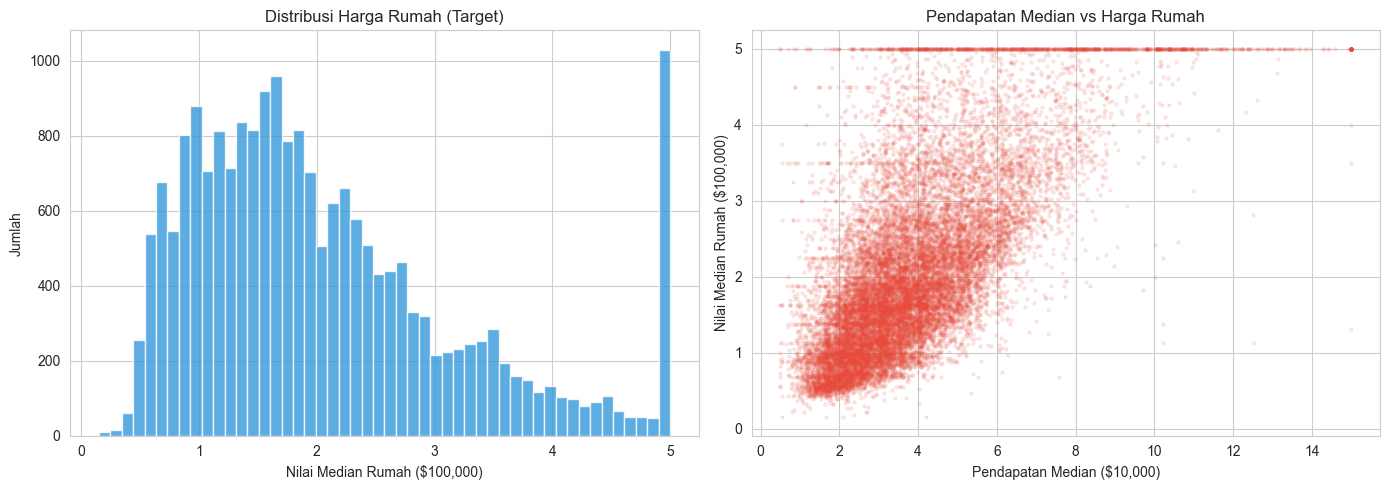

Harga rata-rata: $2.07 × $100,000
Harga min: $0.15 | max: $5.00 × $100,000


In [24]:
# Distribusi target + relasi dengan fitur terkuat
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['MedHouseVal'], bins=50, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribusi Harga Rumah (Target)', fontsize=12)
axes[0].set_xlabel('Nilai Median Rumah ($100,000)')
axes[0].set_ylabel('Jumlah')

axes[1].scatter(df['MedInc'], df['MedHouseVal'], alpha=0.1, color='#e74c3c', s=5)
axes[1].set_title('Pendapatan Median vs Harga Rumah', fontsize=12)
axes[1].set_xlabel('Pendapatan Median ($10,000)')
axes[1].set_ylabel('Nilai Median Rumah ($100,000)')

plt.tight_layout()
plt.show()

print(f"Harga rata-rata: ${df['MedHouseVal'].mean():.2f} × $100,000")
print(f"Harga min: ${df['MedHouseVal'].min():.2f} | max: ${df['MedHouseVal'].max():.2f} × $100,000")

In [25]:
# Train-Test Split dan Scaling
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),      columns=X.columns)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")
print(f"\nFitur yang digunakan: {X_train.columns.tolist()}")
print("\n📌 Scaling PENTING untuk Linear Regression dan KNN (sensitif terhadap skala fitur).")
print("   Random Forest dan XGBoost sebenarnya tidak butuh scaling, tapi tidak ada ruginya.")

X_train: (16512, 8) | X_test: (4128, 8)
y_train: (16512,) | y_test: (4128,)

Fitur yang digunakan: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

📌 Scaling PENTING untuk Linear Regression dan KNN (sensitif terhadap skala fitur).
   Random Forest dan XGBoost sebenarnya tidak butuh scaling, tapi tidak ada ruginya.


---

## BAGIAN 3: Model
### Linear Regression

**Linear Regression** adalah algoritma regresi paling dasar dan selalu dijadikan *baseline*.

Ia mencari **garis (atau hyperplane) lurus terbaik** yang melewati data dengan meminimalkan total error kuadrat (*Ordinary Least Squares*).

```
Formula:
  ŷ = w₁×MedInc + w₂×HouseAge + w₃×AveRooms + ... + b

Di mana:
  ŷ  = harga yang diprediksi
  wᵢ = bobot (koefisien) tiap fitur — dipelajari dari data
  b  = bias/intercept

Tujuan: temukan wᵢ yang meminimalkan:
  Σ (yᵢ - ŷᵢ)²   ← Ordinary Least Squares (OLS)
```

**Kapan cocok?**
- Hubungan antara fitur dan target cukup linear
- Butuh interpretasi koefisien
- Baseline sebelum mencoba model yang lebih kompleks

In [26]:
# Latih Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
y_pred_lr = lr.predict(X_test)

print("=" * 45)
print("LINEAR REGRESSION")
print("=" * 45)
print(f"MAE   : {mean_absolute_error(y_test, y_pred_lr):.4f}")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")
print(f"R²    : {r2_score(y_test, y_pred_lr):.4f}")

LINEAR REGRESSION
MAE   : 0.5332
RMSE  : 0.7456
R²    : 0.5758


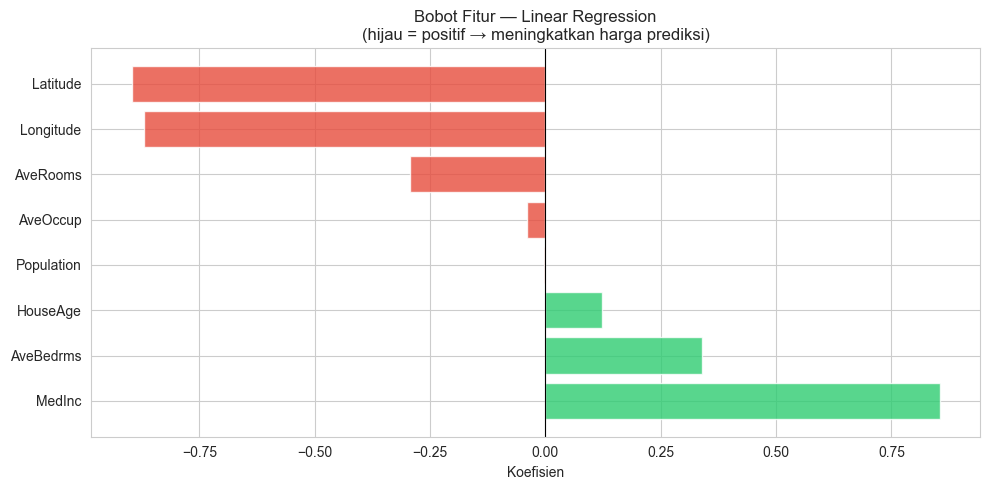

Interpretasi: Koefisien positif → fitur tersebut meningkatkan harga prediksi.
              Koefisien negatif → fitur tersebut menurunkan harga prediksi.


In [28]:
# Visualisasi bobot (koefisien) setiap fitur
koefisien = pd.DataFrame({
    'Fitur'  : X_train.columns,
    'Bobot'  : lr.coef_
}).sort_values('Bobot', ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in koefisien['Bobot']]
plt.barh(koefisien['Fitur'], koefisien['Bobot'], color=colors, alpha=0.8, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Bobot Fitur — Linear Regression\n(hijau = positif → meningkatkan harga prediksi)', fontsize=12)
plt.xlabel('Koefisien')
plt.tight_layout()
plt.show()

print("Interpretasi: Koefisien positif → fitur tersebut meningkatkan harga prediksi.")
print("              Koefisien negatif → fitur tersebut menurunkan harga prediksi.")

#### Parameter Sensitivity — Ridge Regularization

Varian **Ridge Regression** menambahkan penalti regularization untuk mencegah overfitting:

```
Ridge: minimasi  Σ(yᵢ - ŷᵢ)²  +  α × Σwᵢ²
                 ─────────────    ──────────
                 fit ke data      penalti bobot besar

α besar → penalti kuat → bobot dipaksa kecil (bisa underfit)
α kecil → penalti lemah → mirip Linear Regression biasa
```

> Kebalikan dari `C` di Logistic Regression: **makin besar α = makin kuat regularization**.

In [29]:
# Eksperimen: Pengaruh nilai alpha terhadap performa Ridge Regression
alpha_values = [0.01, 1, 100]

print("=" * 50)
print("Ridge Regression — Efek Regularization (α)")
print("=" * 50)

for a in alpha_values:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    y_pred_a = ridge.predict(X_test)
    r2   = r2_score(y_test, y_pred_a)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_a))
    print(f"  α={a:<6} → R²: {r2:.4f}  |  RMSE: {rmse:.4f}")

print("\n💡 Makin besar α, makin kuat regularization — model jadi lebih sederhana.")

Ridge Regression — Efek Regularization (α)
  α=0.01   → R²: 0.5758  |  RMSE: 0.7456
  α=1      → R²: 0.5758  |  RMSE: 0.7456
  α=100    → R²: 0.5778  |  RMSE: 0.7438

💡 Makin besar α, makin kuat regularization — model jadi lebih sederhana.


---

### KNN Regressor

**K-Nearest Neighbors (KNN) Regressor** adalah algoritma paling intuitif: untuk memprediksi nilai suatu titik, cari K titik training yang **paling mirip** (paling dekat secara jarak), lalu ambil **rata-ratanya**.

```
Contoh prediksi harga rumah baru (★):

  Data training:
  ● $2.1  ● $1.9     ← 2 tetangga terdekat (K=3)
     ● $2.3           ← tetangga ke-3
        ★ ???         ← titik yang ingin diprediksi
           ● $3.5     ← tidak masuk K=3

  Prediksi = rata-rata K tetangga = (2.1 + 1.9 + 2.3) / 3 = 2.1
```

**Parameter penting:**
- `n_neighbors` (K): jumlah tetangga — kecil = kompleks (overfit), besar = sederhana (underfit)
- `weights`: `uniform` (rata-rata biasa) atau `distance` (tetangga dekat lebih berpengaruh)

**⚠️ Scaling wajib!** KNN menggunakan jarak — fitur dengan skala besar akan mendominasi.

**Kelebihan:**
- Sangat intuitif dan mudah dipahami
- Tidak ada proses training (*lazy learner*)
- Bisa menangkap pola non-linear

**Kekurangan:**
- Lambat saat prediksi untuk dataset besar
- Tidak memberikan feature importance

In [30]:
# Latih KNN Regressor
knn = KNeighborsRegressor(n_neighbors=10, weights='distance')
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [31]:
y_pred_knn = knn.predict(X_test)

print("=" * 45)
print("KNN REGRESSOR (K=10, weights=distance)")
print("=" * 45)
print(f"MAE   : {mean_absolute_error(y_test, y_pred_knn):.4f}")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_test, y_pred_knn)):.4f}")
print(f"R²    : {r2_score(y_test, y_pred_knn):.4f}")

KNN REGRESSOR (K=10, weights=distance)
MAE   : 0.4368
RMSE  : 0.6452
R²    : 0.6823


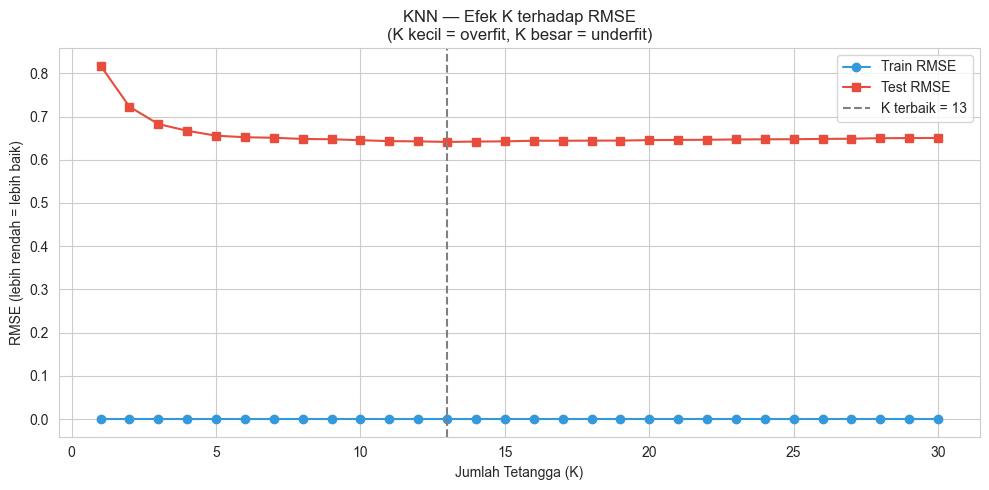


💡 K terbaik (test RMSE minimum): 13
   K=1 → hafal data training (train RMSE≈0, test RMSE buruk).
   K terlalu besar → model terlalu 'tumpul', tidak bisa menangkap pola lokal.


In [32]:
# Efek nilai K terhadap RMSE — bias-variance tradeoff
k_values   = range(1, 31)
train_rmse = []
test_rmse  = []

for k in k_values:
    m = KNeighborsRegressor(n_neighbors=k, weights='distance')
    m.fit(X_train, y_train)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train))))
    test_rmse.append(np.sqrt(mean_squared_error(y_test,  m.predict(X_test))))

best_k = list(k_values)[np.argmin(test_rmse)]

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_rmse, 'o-', label='Train RMSE', color='#3498db')
plt.plot(k_values, test_rmse,  's-', label='Test RMSE',  color='#e74c3c')
plt.axvline(best_k, color='gray', linestyle='--', label=f'K terbaik = {best_k}')
plt.xlabel('Jumlah Tetangga (K)')
plt.ylabel('RMSE (lebih rendah = lebih baik)')
plt.title('KNN — Efek K terhadap RMSE\n(K kecil = overfit, K besar = underfit)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n💡 K terbaik (test RMSE minimum): {best_k}")
print("   K=1 → hafal data training (train RMSE≈0, test RMSE buruk).")
print("   K terlalu besar → model terlalu 'tumpul', tidak bisa menangkap pola lokal.")

---

### Random Forest Regressor

**Random Forest Regressor** adalah kumpulan banyak Decision Tree Regressor yang bekerja bersama (**ensemble — bagging**).

Setiap pohon dilatih pada **subset acak** dari data dan fitur. Prediksi akhir = **rata-rata** prediksi semua pohon.

```
                    DATA TRAINING
                        │
          ┌─────────────┼─────────────┐
          │             │             │
       Tree 1        Tree 2  ...   Tree N
       (subset 1)    (subset 2)    (subset N)
          │             │             │
       ŷ=2.35        ŷ=2.18        ŷ=2.41
          │             │             │
          └─────────────┼─────────────┘
                   RATA-RATA
                  ŷ_final = 2.31
```

**Kelebihan:**
- Lebih tahan overfitting dibanding satu pohon
- Akurasi tinggi, feature importance bawaan

**Kekurangan:**
- Lebih lambat, kurang interpretable

In [33]:
# Latih Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [34]:
y_pred_rf = rf.predict(X_test)

print("=" * 50)
print("RANDOM FOREST REGRESSOR (100 trees, max_depth=10)")
print("=" * 50)
print(f"MAE   : {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")
print(f"R²    : {r2_score(y_test, y_pred_rf):.4f}")

RANDOM FOREST REGRESSOR (100 trees, max_depth=10)
MAE   : 0.3663
RMSE  : 0.5443
R²    : 0.7739


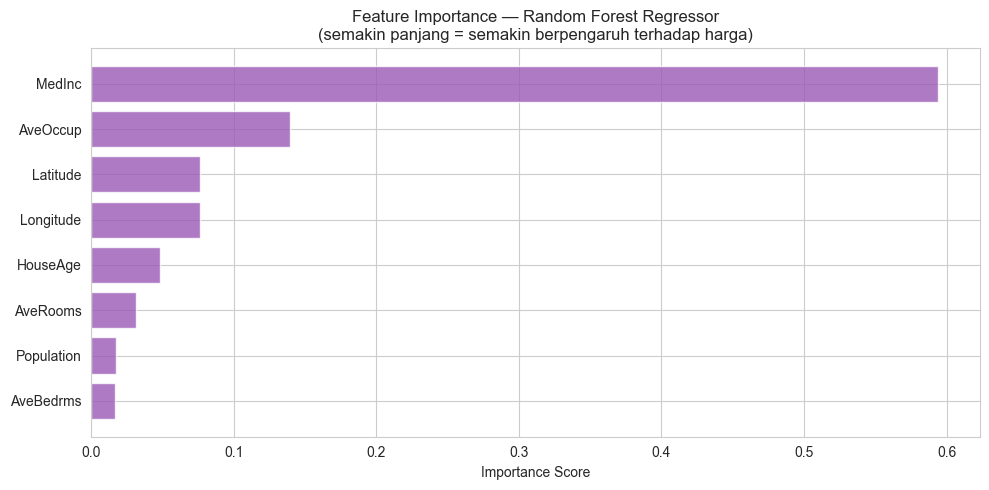

In [35]:
# Feature Importance dari Random Forest
importances = pd.DataFrame({
    'Fitur'      : X_train.columns,
    'Importance' : rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(importances['Fitur'], importances['Importance'],
         color='#9b59b6', alpha=0.8, edgecolor='white')
plt.title('Feature Importance — Random Forest Regressor\n(semakin panjang = semakin berpengaruh terhadap harga)', fontsize=12)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

---

### XGBoost Regressor

**XGBoost** (*Extreme Gradient Boosting*) adalah salah satu algoritma ML paling populer untuk data tabular. Berbeda dari Random Forest (**bagging** — pohon dibuat paralel secara independen), XGBoost menggunakan **boosting** — setiap pohon baru belajar dari **error pohon sebelumnya**.

```
Bagging (Random Forest):      Boosting (XGBoost):
────────────────────          ───────────────────────
Tree 1 ─┐                     Tree 1
Tree 2 ─┤ → RATA-RATA          ↓ (pelajari error Tree 1)
Tree 3 ─┘                     Tree 2
(paralel, independen)          ↓ (pelajari error Tree 2)
                               Tree 3
                               (sekuensial, tiap pohon koreksi sebelumnya)
```

**Parameter penting:**
- `n_estimators`: jumlah iterasi boosting (jumlah pohon)
- `max_depth`: kedalaman maksimal tiap pohon
- `learning_rate` (η): seberapa besar langkah koreksi tiap iterasi

```
learning_rate kecil → koreksi kecil → butuh lebih banyak pohon, tapi lebih hati-hati
learning_rate besar → koreksi besar → konvergen cepat, tapi bisa overshoot
```

**Kapan cocok?**
- Data tabular — XGBoost hampir selalu kompetitif
- Kompetisi ML (Kaggle) — XGBoost adalah pilihan dominan
- Ketika butuh akurasi maksimal

In [41]:
# Latih XGBoost Regressor
XGBOOST_AVAILABLE
xgb = XGBRegressor (
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
    )
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [42]:
if XGBOOST_AVAILABLE:
    y_pred_xgb = xgb.predict(X_test)

    print("=" * 50)
    print("XGBOOST REGRESSOR (300 trees, lr=0.05)")
    print("=" * 50)
    print(f"MAE   : {mean_absolute_error(y_test, y_pred_xgb):.4f}")
    print(f"RMSE  : {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.4f}")
    print(f"R²    : {r2_score(y_test, y_pred_xgb):.4f}")

XGBOOST REGRESSOR (300 trees, lr=0.05)
MAE   : 0.2996
RMSE  : 0.4565
R²    : 0.8410


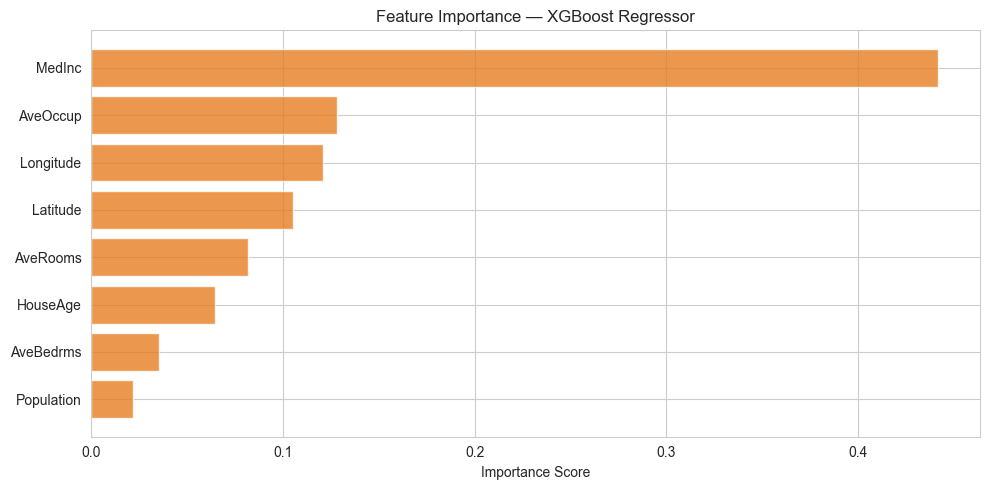

In [43]:
# Feature Importance XGBoost
if XGBOOST_AVAILABLE:
    importances_xgb = pd.DataFrame({
        'Fitur'      : X_train.columns,
        'Importance' : xgb.feature_importances_
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 5))
    plt.barh(importances_xgb['Fitur'], importances_xgb['Importance'],
             color='#e67e22', alpha=0.8, edgecolor='white')
    plt.title('Feature Importance — XGBoost Regressor', fontsize=12)
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

In [44]:
# Eksperimen: Pengaruh learning_rate terhadap performa XGBoost
if XGBOOST_AVAILABLE:
    lr_values = [0.001, 0.01, 0.05, 0.1, 0.3]

    print("=" * 55)
    print("XGBoost — Efek Learning Rate (n_estimators=300)")
    print("=" * 55)

    for lr_val in lr_values:
        m = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=lr_val,
                         random_state=42, verbosity=0)
        m.fit(X_train, y_train)
        rmse = np.sqrt(mean_squared_error(y_test, m.predict(X_test)))
        r2   = r2_score(y_test, m.predict(X_test))
        print(f"  lr={lr_val:<6} → RMSE: {rmse:.4f}  |  R²: {r2:.4f}")

    print("\n💡 lr terlalu kecil → belajar lambat, butuh lebih banyak pohon.")
    print("   lr terlalu besar → overshoot, konvergensi tidak stabil.")

XGBoost — Efek Learning Rate (n_estimators=300)
  lr=0.001  → RMSE: 0.9592  |  R²: 0.2979
  lr=0.01   → RMSE: 0.5483  |  R²: 0.7705
  lr=0.05   → RMSE: 0.4670  |  R²: 0.8336
  lr=0.1    → RMSE: 0.4566  |  R²: 0.8409
  lr=0.3    → RMSE: 0.4707  |  R²: 0.8309

💡 lr terlalu kecil → belajar lambat, butuh lebih banyak pohon.
   lr terlalu besar → overshoot, konvergensi tidak stabil.


---

## BAGIAN 4: Evaluasi Model

### Metrik Regresi

Tidak seperti klasifikasi yang menggunakan Accuracy/F1, regresi menggunakan metrik yang mengukur **seberapa jauh prediksi dari nilai aktual**.

```
Aktual (yᵢ):   3.0,  5.0,  2.5,  4.8
Prediksi (ŷᵢ): 3.2,  4.6,  2.9,  4.1
Error (eᵢ):    0.2, -0.4,  0.4, -0.7
```

| Metrik | Rumus | Interpretasi |
|--------|-------|--------------|
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Rata-rata error absolut — mudah dipahami, satuan sama dengan target |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Seperti MAE tapi lebih menghukum error besar |
| **R²** | $1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$ | Proporsi variansi yang dijelaskan model (0–1, makin tinggi makin baik) |

**Interpretasi R²:**
```
R² = 0.0  → sama buruknya dengan hanya menebak rata-rata
R² = 0.7  → model menjelaskan 70% variasi data
R² = 1.0  → prediksi sempurna (hati-hati: bisa overfit!)
```

> Gunakan **RMSE** untuk membandingkan model. Gunakan **R²** untuk menjelaskan performa ke stakeholder.

In [45]:
# Susun daftar model dan prediksi
model_list = [
    (y_pred_lr,  'Linear Regression', '#3498db'),
    (y_pred_knn, 'KNN Regressor',     '#27ae60'),
    (y_pred_rf,  'Random Forest',     '#9b59b6'),
    (y_pred_xgb, 'XGBoost',           '#e67e22')
]
ncols = len(model_list)

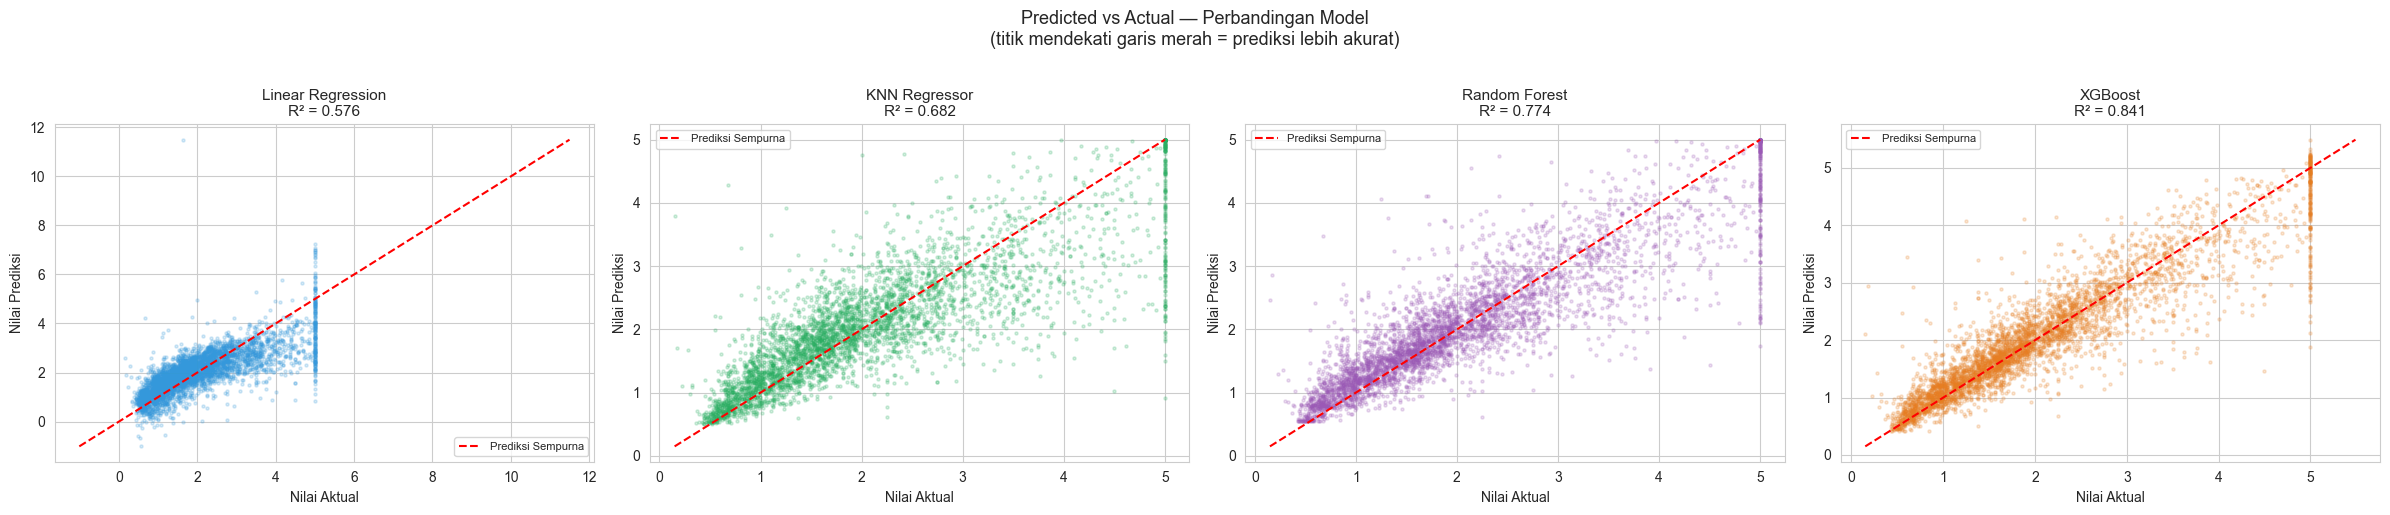

In [46]:
# Predicted vs Actual — visualisasi utama untuk evaluasi regresi
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
if ncols == 1:
    axes = [axes]

for ax, (y_pred, nama, warna) in zip(axes, model_list):
    ax.scatter(y_test, y_pred, alpha=0.2, s=5, color=warna)
    batas = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(batas, batas, 'r--', linewidth=1.5, label='Prediksi Sempurna')
    ax.set_title(f'{nama}\nR² = {r2_score(y_test, y_pred):.3f}', fontsize=11)
    ax.set_xlabel('Nilai Aktual')
    ax.set_ylabel('Nilai Prediksi')
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual — Perbandingan Model\n(titik mendekati garis merah = prediksi lebih akurat)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

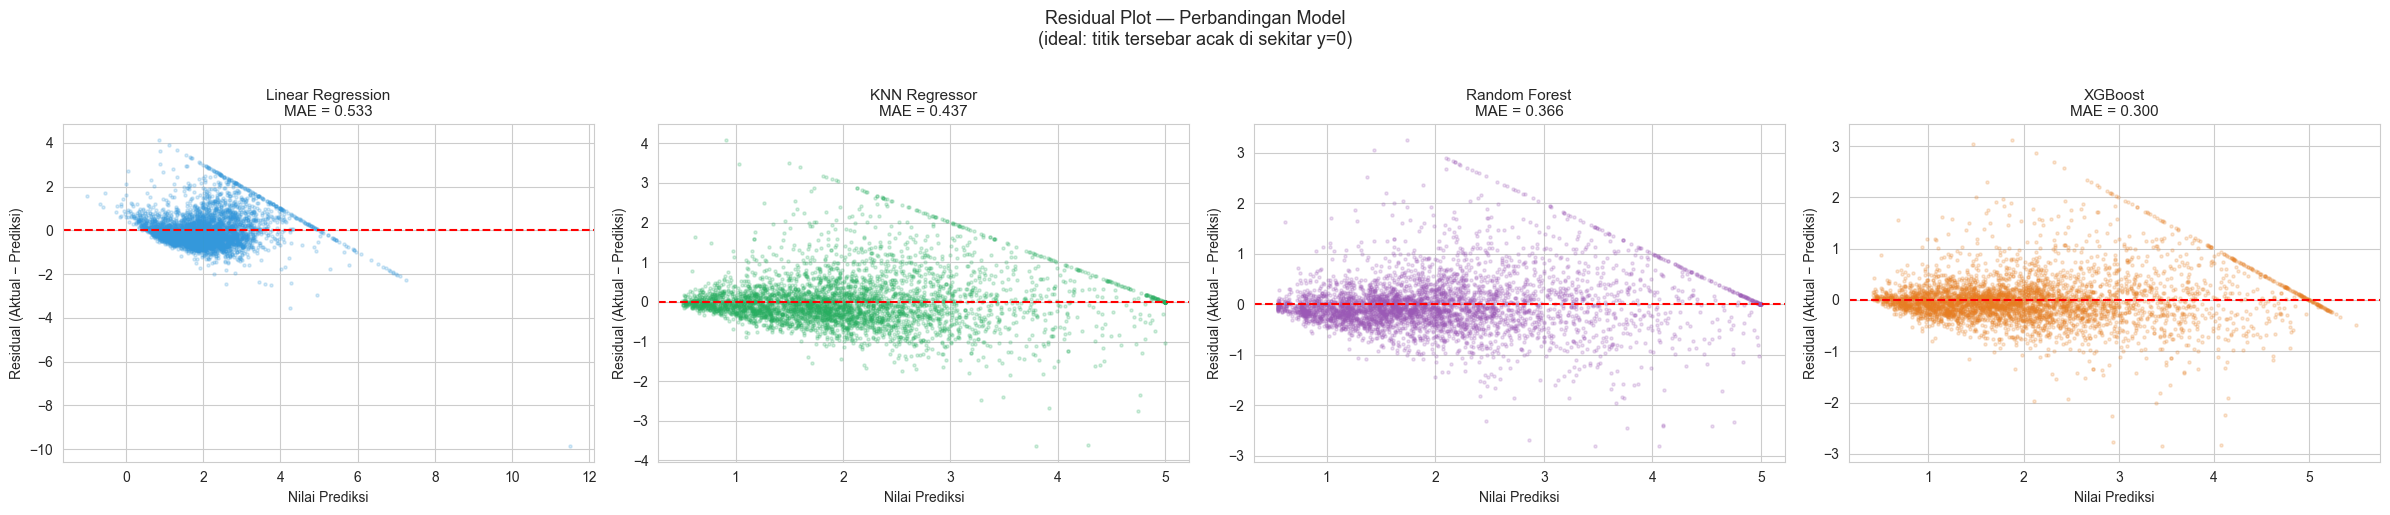


📌 Jika residual membentuk pola (corong, lengkung, cluster) → ada asumsi yang dilanggar.
   Residual acak di sekitar y=0 → model sudah baik.


In [47]:
# Residual Plot — mendeteksi pola error sistematis
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
if ncols == 1:
    axes = [axes]

for ax, (y_pred, nama, warna) in zip(axes, model_list):
    residuals = y_test.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.2, s=5, color=warna)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'{nama}\nMAE = {mean_absolute_error(y_test, y_pred):.3f}', fontsize=11)
    ax.set_xlabel('Nilai Prediksi')
    ax.set_ylabel('Residual (Aktual − Prediksi)')

plt.suptitle('Residual Plot — Perbandingan Model\n(ideal: titik tersebar acak di sekitar y=0)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\n📌 Jika residual membentuk pola (corong, lengkung, cluster) → ada asumsi yang dilanggar.")
print("   Residual acak di sekitar y=0 → model sudah baik.")

            Model    MAE   RMSE     R²
Linear Regression 0.5332 0.7456 0.5758
    KNN Regressor 0.4368 0.6452 0.6823
    Random Forest 0.3663 0.5443 0.7739
          XGBoost 0.2996 0.4565 0.8410


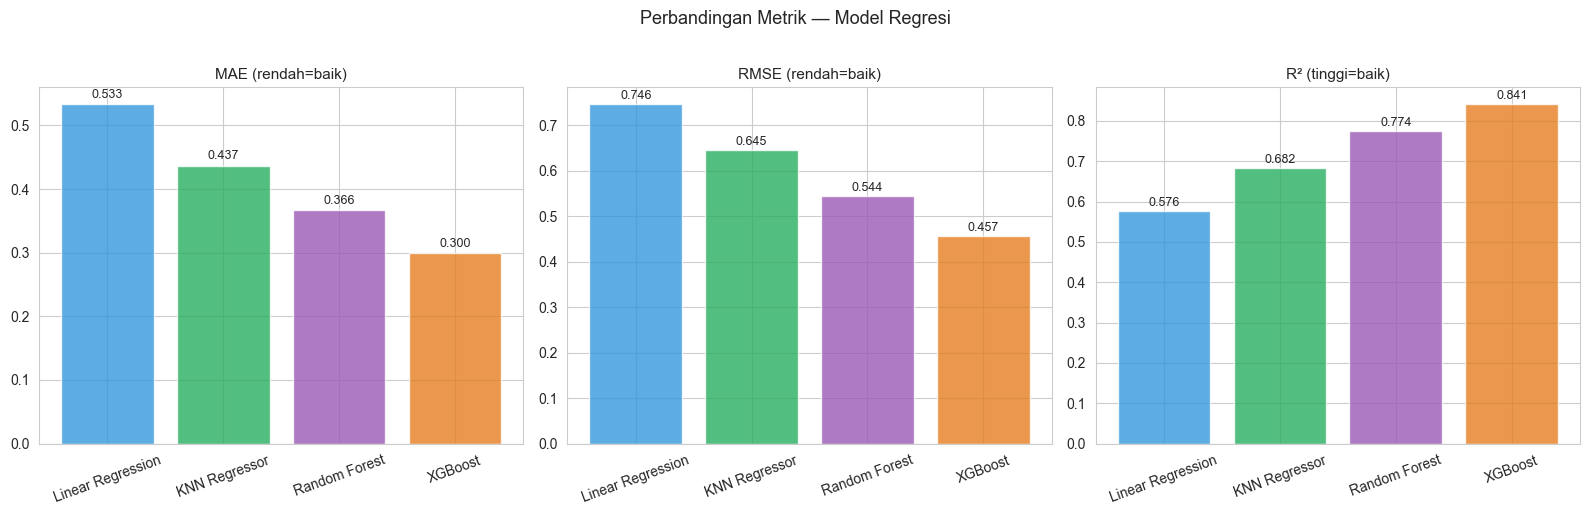

In [48]:
# Tabel perbandingan semua metrik
hasil = []
for y_pred, nama, _ in model_list:
    hasil.append({
        'Model': nama,
        'MAE'  : round(mean_absolute_error(y_test, y_pred),             4),
        'RMSE' : round(np.sqrt(mean_squared_error(y_test, y_pred)),     4),
        'R²'   : round(r2_score(y_test, y_pred),                        4),
    })

df_hasil = pd.DataFrame(hasil)
print(df_hasil.to_string(index=False))

# Bar chart perbandingan
warna_model = ['#3498db', '#27ae60', '#9b59b6', '#e67e22']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metrik, arah) in zip(axes, [('MAE', 'rendah=baik'), ('RMSE', 'rendah=baik'), ('R²', 'tinggi=baik')]):
    bars = ax.bar(df_hasil['Model'], df_hasil[metrik],
                  color=warna_model[:len(df_hasil)], alpha=0.8, edgecolor='white')
    ax.set_title(f'{metrik} ({arah})', fontsize=11)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, df_hasil[metrik]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Perbandingan Metrik — Model Regresi', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

### Cross-Validation: Evaluasi yang Lebih Robust

Sama seperti klasifikasi, gunakan **Cross-Validation** untuk estimasi performa yang lebih stabil.

```
     Fold 1  Fold 2  Fold 3  Fold 4  Fold 5
     +------+------+------+------+------+
     | Val  | Train| Train| Train| Train|  → RMSE ke-1
     +------+------+------+------+------+
     |Train | Val  | Train| Train| Train|  → RMSE ke-2
     +------+------+------+------+------+
     |Train |Train | Val  | Train| Train|  → RMSE ke-3
     +------+------+------+------+------+
     |Train |Train |Train | Val  | Train|  → RMSE ke-4
     +------+------+------+------+------+
     |Train |Train |Train |Train | Val  |  → RMSE ke-5
     +------+------+------+------+------+
               Hasil = rata-rata ± std
```

In [50]:
# Cross-Validation dengan 5-fold untuk semua model
models_cv = [
    ('Linear Regression', LinearRegression()),
    ('KNN Regressor',     KNeighborsRegressor(n_neighbors=10, weights='distance')),
    ('Random Forest',     RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)),
    ('XGBoost',           XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.05, random_state=42, verbosity=0))
]

print("=" * 60)
print("CROSS-VALIDATION (5-fold) — RMSE")
print("=" * 60)

for nama, model in models_cv:
    scores = cross_val_score(model, X_train, y_train, cv=5,
                             scoring='neg_root_mean_squared_error')
    print(f"  {nama:<22} → {-scores.mean():.4f} ± {scores.std():.4f}")

print("\n💡 Bandingkan dengan hasil train-test split sebelumnya.")
print("   CV memberikan estimasi yang lebih stabil karena diuji 5 kali.")

CROSS-VALIDATION (5-fold) — RMSE
  Linear Regression      → 0.7205 ± 0.0103
  KNN Regressor          → 0.6375 ± 0.0122
  Random Forest          → 0.5415 ± 0.0056
  XGBoost                → 0.4988 ± 0.0052

💡 Bandingkan dengan hasil train-test split sebelumnya.
   CV memberikan estimasi yang lebih stabil karena diuji 5 kali.


---

## ✏️ Latihan Mandiri

Kerjakan soal berikut menggunakan **dataset tim kamu sendiri** (bukan California Housing):

In [ ]:
# LATIHAN 1: Ganti dengan dataset timmu
# 1. Load dataset tim kamu (pastikan sudah di-clean dan di-prepare)
# 2. Pilih kolom target yang kontinu (bukan kategori)
# 3. Lakukan train-test split (80:20) dan scaling
# 4. Latih keempat model: Linear Regression, KNN, Random Forest, XGBoost
# 5. Cetak MAE, RMSE, dan R² untuk setiap model

# Tulis kode di sini:


In [ ]:
# LATIHAN 2: Hyperparameter tuning KNN
# Coba variasikan n_neighbors dari 1 sampai 30 menggunakan dataset timmu
# Plot train RMSE vs test RMSE
# Tentukan K terbaik dan jelaskan alasannya

# Tulis kode di sini:


In [ ]:
# LATIHAN 3 (Tantangan): Analisis Residual + Interpretasi
# 1. Latih model terbaik dari Latihan 1
# 2. Buat Predicted vs Actual plot
# 3. Buat Residual plot
# 4. Identifikasi: apakah ada pola pada residual? Apa artinya?
# 5. Tulis 2-3 kalimat kesimpulan: model mana terbaik? mengapa?

# Tulis kode dan analisis di sini:


---

## 📝 Ringkasan Pertemuan 10

```
REGRESI — ALUR LENGKAP

DATA SIAP ML (dari P7)
    ↓
[P10] Pilih Algoritma Regresi
        ├── Linear Regression  → baseline, interpretable, asumsi linear
        ├── KNN Regressor      → intuitif, non-parametrik, butuh scaling
        ├── Random Forest      → ensemble bagging, robust, feature importance
        └── XGBoost            → ensemble boosting, akurasi tinggi, industri
    ↓
[P10] model.fit(X_train, y_train)
    ↓
[P10] y_pred = model.predict(X_test)
    ↓
[P10] Evaluasi
        ├── MAE    → rata-rata error absolut, mudah dipahami
        ├── RMSE   → lebih sensitif terhadap error besar
        ├── R²     → proporsi variansi yang dijelaskan model
        ├── Predicted vs Actual → cek kalibrasi
        └── Residual Plot       → cek error sistematis
```

### Perbandingan 4 Algoritma

| Algoritma | Interpretable | Butuh Scaling | Feature Importance | Kapan Pakai |
|-----------|:---:|:---:|:---:|-------------|
| **Linear Regression** | ✅ Tinggi | ✅ Ya | Koefisien | Baseline, hubungan linear |
| **KNN Regressor** | ✅ Sedang | ✅ Ya | ❌ Tidak | Dataset kecil, non-linear |
| **Random Forest** | ❌ Rendah | ❌ Opsional | ✅ Ada | Dataset sedang-besar, general |
| **XGBoost** | ❌ Rendah | ❌ Opsional | ✅ Ada | Performa max, kompetisi/produksi |

---

**Pertemuan berikutnya: Python ML — Clustering** 🔵🟢🔴  
Dari prediksi nilai → menemukan kelompok tersembunyi dalam data tanpa label (*unsupervised learning*)